# 02B — Gaussian Beam in a Fabry–Pérot Optical Cavity

## Purpose

This notebook develops the Gaussian-beam description of a short two-mirror Fabry–Pérot cavity and connects the spatial mode to the longitudinal cavity resonance and circulating power.

We begin with a **symmetric spherical cavity**, where the Gaussian mode can be obtained directly from the cavity geometry. We then discuss what changes when the cavity is made **asymmetric**, without yet using the full ABCD-matrix method. The ABCD treatment is developed separately in **02C**.

The model is a passive optical cavity. No nonlinear crystal is included yet.

### Physical progression

$$
\text{cavity geometry}
\rightarrow
\text{stability}
\rightarrow
\text{Gaussian mode}
\rightarrow
\text{circulating power}
\rightarrow
\text{Gaussian intensity}.
$$

The eventual OPO system will use this as the linear optical foundation before nonlinear parametric interaction is introduced.

## 1. Physical picture

A Gaussian beam inside a stable optical cavity is not arbitrary. The cavity geometry selects a self-consistent spatial mode.

There are two related but distinct questions:

1. **Longitudinal resonance:** does the returning optical field have the correct phase to reinforce the intracavity field?
2. **Transverse stability:** does the cavity support a self-consistent Gaussian spatial mode?

A useful passive-cavity picture is therefore:

$$
\boxed{\text{resonance determines circulating power}}
$$

while

$$
\boxed{\text{cavity geometry determines the Gaussian mode}}.
$$

Later, the two are combined to obtain the spatial intensity inside the cavity.

## 2. Cavity parameters

We use the same representative short cavity throughout this notebook.

- Wavelength: $\lambda_0=1064$ nm
- Cavity length: $L=0.50$ m
- Symmetric mirror curvature: $ROC_1=ROC_2=1.00$ m
- Illustrative mirror power reflectivity: $R_1=R_2=0.99$
- Incident power: $P_{\rm in}=1$ W

The numerical values are pedagogical values for studying the model. They are not final parameters for a gravitational-wave OPO.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

c = 299_792_458.0
pi = np.pi

lambda0 = 1064e-9
nu0 = c / lambda0

L = 0.50
ROC1 = 1.00
ROC2 = 1.00

mirror_R1 = 0.99
mirror_R2 = 0.99

mirror_T1 = 1 - mirror_R1
mirror_T2 = 1 - mirror_R2

T_rt_internal = 1.0
P_in = 1.0

print(f"Wavelength = {lambda0*1e9:.1f} nm")
print(f"Optical frequency = {nu0/1e12:.3f} THz")
print(f"Cavity length = {L:.3f} m")
print(f"ROC1 = {ROC1:.3f} m, ROC2 = {ROC2:.3f} m")
print(f"Power reflectivities = {mirror_R1:.4f}, {mirror_R2:.4f}")
print(f"Input power = {P_in:.3f} W")

Wavelength = 1064.0 nm
Optical frequency = 281.760 THz
Cavity length = 0.500 m
ROC1 = 1.000 m, ROC2 = 1.000 m
Power reflectivities = 0.9900, 0.9900
Input power = 1.000 W


## 3. Longitudinal resonance and free spectral range

For a vacuum Fabry–Pérot cavity of geometrical length $L$, the round-trip phase is

$$
\phi_{\rm rt}=\frac{4\pi\nu L}{c}.
$$

Changing the optical frequency by one free spectral range changes the round-trip phase by $2\pi$. Therefore

$$
\boxed{\mathrm{FSR}=\frac{c}{2L}}.
$$

Near one longitudinal resonance we define the frequency detuning $\delta\nu$ and write

$$
\phi=2\pi\frac{\delta\nu}{\mathrm{FSR}}.
$$

For $L=0.50$ m, the FSR is approximately $300$ MHz.

FSR = 299.792 MHz


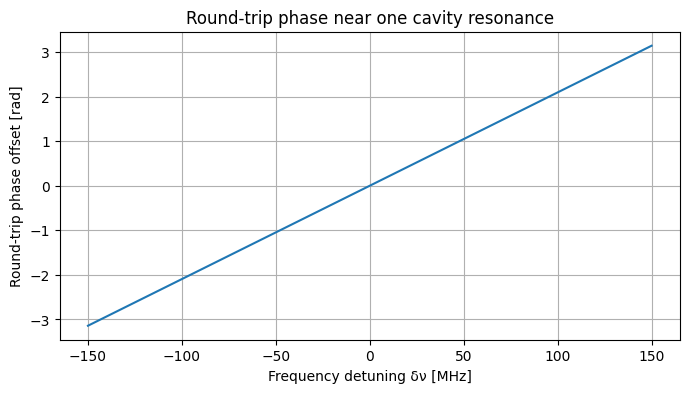

In [2]:
FSR = c / (2 * L)
delta_nu = np.linspace(-FSR/2, FSR/2, 4000)
phi = 2 * pi * delta_nu / FSR

print(f"FSR = {FSR/1e6:.3f} MHz")

plt.figure(figsize=(8, 4))
plt.plot(delta_nu/1e6, phi)
plt.xlabel("Frequency detuning δν [MHz]")
plt.ylabel("Round-trip phase offset [rad]")
plt.title("Round-trip phase near one cavity resonance")
plt.grid(True)
plt.show()

## 4. Intracavity power buildup

For a two-mirror cavity with internal round-trip **power transmission** $T_{\rm rt}$,

$$
\boxed{
B(\phi)=\frac{P_{\rm cav}}{P_{\rm in}}
=
\frac{T_1}
{1+R_1R_2T_{\rm rt}
-2\sqrt{R_1R_2T_{\rm rt}}\cos\phi}
}.
$$

Thus

$$
P_{\rm cav}(\delta\nu)=B(\delta\nu)P_{\rm in}.
$$

This is **passive cavity buildup**, not nonlinear gain. The cavity stores energy supplied by the input field; constructive interference allows the circulating power to become much larger than the incident power.

Resonant power buildup = 100.000
Resonant circulating power = 100.000 W


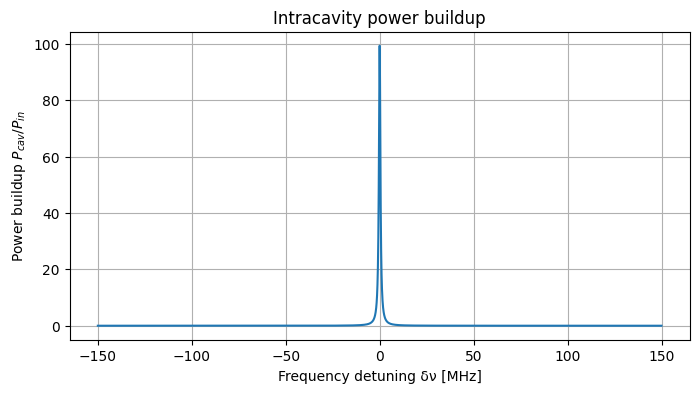

In [3]:
def cavity_buildup(delta_nu, L, R1, R2, T1, T_rt=1.0):
    FSR_local = c / (2 * L)
    phi_local = 2 * pi * delta_nu / FSR_local

    denominator = (
        1
        + R1 * R2 * T_rt
        - 2 * np.sqrt(R1 * R2 * T_rt) * np.cos(phi_local)
    )

    return T1 / denominator

B = cavity_buildup(
    delta_nu, L, mirror_R1, mirror_R2, mirror_T1, T_rt_internal
)

P_cav = B * P_in

B_res = cavity_buildup(
    np.array([0.0]), L, mirror_R1, mirror_R2, mirror_T1, T_rt_internal
)[0]

P_cav_res = B_res * P_in

print(f"Resonant power buildup = {B_res:.3f}")
print(f"Resonant circulating power = {P_cav_res:.3f} W")

plt.figure(figsize=(8, 4))
plt.plot(delta_nu/1e6, B)
plt.xlabel("Frequency detuning δν [MHz]")
plt.ylabel("Power buildup $P_{cav}/P_{in}$")
plt.title("Intracavity power buildup")
plt.grid(True)
plt.show()

## 5. Finesse and linewidth

On resonance,

$$
\boxed{
B_{\rm res}
=
\frac{T_1}
{\left(1-\sqrt{R_1R_2T_{\rm rt}}\right)^2}
}.
$$

For a high-finesse cavity,

$$
\boxed{
\mathcal F
\approx
\frac{\pi(R_1R_2T_{\rm rt})^{1/4}}
{1-\sqrt{R_1R_2T_{\rm rt}}}
}
$$

and approximately

$$
\boxed{\Delta\nu=\frac{\mathrm{FSR}}{\mathcal F}}.
$$

For symmetric lossless mirrors,

$$
\mathcal F\approx\frac{\pi\sqrt R}{1-R}.
$$

In [4]:
F = (
    pi * (mirror_R1 * mirror_R2 * T_rt_internal)**0.25
    / (1 - np.sqrt(mirror_R1 * mirror_R2 * T_rt_internal))
)

linewidth = FSR / F

print(f"Finesse ≈ {F:.2f}")
print(f"Linewidth ≈ {linewidth/1e6:.3f} MHz")
print(f"FSR / linewidth ≈ {FSR/linewidth:.2f}")

half_max = B_res / 2
mask = B >= half_max
fwhm_sampled = delta_nu[mask][-1] - delta_nu[mask][0]

print(f"Sampled FWHM ≈ {fwhm_sampled/1e6:.3f} MHz")

Finesse ≈ 312.58
Linewidth ≈ 0.959 MHz
FSR / linewidth ≈ 312.58
Sampled FWHM ≈ 0.825 MHz


## 6. Gaussian cavity mode and stability

For a two-mirror spherical cavity,

$$
g_1=1-\frac{L}{ROC_1},
\qquad
g_2=1-\frac{L}{ROC_2}.
$$

The usual two-mirror stability condition is

$$
\boxed{0<g_1g_2<1}.
$$

For the symmetric example,

$$
g_1=g_2=0.5,
\qquad
g_1g_2=0.25.
$$

Therefore the cavity is geometrically stable.

Longitudinal resonance and transverse stability are separate requirements: a cavity can have a well-defined FSR while its transverse geometry is unstable.

In [5]:
g1 = 1 - L / ROC1
g2 = 1 - L / ROC2
g_product = g1 * g2

print(f"g1 = {g1:.4f}")
print(f"g2 = {g2:.4f}")
print(f"g1 * g2 = {g_product:.4f}")
print(f"Stable by simple criterion? {0 < g_product < 1}")

g1 = 0.5000
g2 = 0.5000
g1 * g2 = 0.2500
Stable by simple criterion? True


## 7. Symmetric cavity: waist and Rayleigh range

For the symmetric cavity $ROC_1=ROC_2=ROC$, the waist is at the cavity centre:

$$
z_{\rm waist}=\frac{L}{2}
$$

when the coordinate is measured from either mirror.

The Rayleigh range is

$$
\boxed{
z_R=
\sqrt{
\frac{L}{2}
\left(
ROC-\frac{L}{2}
\right)
}
}.
$$

The waist radius is

$$
\boxed{
w_0=\sqrt{\frac{\lambda_0z_R}{\pi}}
}.
$$

The Gaussian radius at a distance $z$ from the waist is

$$
\boxed{
w(z)=w_0\sqrt{1+\left(\frac{z}{z_R}\right)^2}
}.
$$

In [6]:
zR = np.sqrt((L/2) * (ROC1 - L/2))
w0 = np.sqrt(lambda0 * zR / pi)

z_mirror = L / 2
w_mirror = w0 * np.sqrt(1 + (z_mirror/zR)**2)

print(f"Rayleigh range z_R = {zR:.6f} m")
print(f"Waist radius w_0 = {w0*1e3:.6f} mm")
print(f"Beam radius at both mirrors = {w_mirror*1e3:.6f} mm")

Rayleigh range z_R = 0.433013 m
Waist radius w_0 = 0.382954 mm
Beam radius at both mirrors = 0.442197 mm


## 8. Beam propagation and Gaussian wavefront curvature

Using a coordinate $z$ measured from the waist,

$$
w(z)=w_0\sqrt{1+\left(\frac{z}{z_R}\right)^2}.
$$

The Gaussian wavefront radius of curvature is

$$
\boxed{
R_{\rm wf}(z)
=
z\left[
1+\left(\frac{z_R}{z}\right)^2
\right]
}.
$$

At the spherical mirrors, the Gaussian wavefront curvature must match the mirror curvature in magnitude:

$$
|R_{\rm wf}|=ROC.
$$

This is the spatial self-consistency condition for the symmetric cavity.

Wavefront radius at mirror 1 = -1.000000 m
Wavefront radius at mirror 2 = 1.000000 m


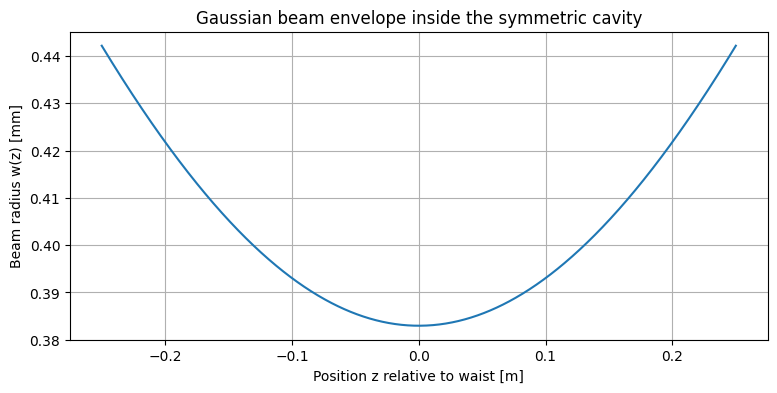

In [7]:
z = np.linspace(-L/2, L/2, 1000)
w = w0 * np.sqrt(1 + (z/zR)**2)

def wavefront_radius(z, zR):
    z = np.asarray(z, dtype=float)
    R = np.empty_like(z)

    zero = np.isclose(z, 0)
    R[zero] = np.inf

    nonzero = ~zero
    R[nonzero] = z[nonzero] * (1 + (zR/z[nonzero])**2)

    return R

Rwf = wavefront_radius(z, zR)

print(f"Wavefront radius at mirror 1 = {Rwf[0]:.6f} m")
print(f"Wavefront radius at mirror 2 = {Rwf[-1]:.6f} m")

plt.figure(figsize=(9, 4))
plt.plot(z, w*1e3)
plt.xlabel("Position z relative to waist [m]")
plt.ylabel("Beam radius w(z) [mm]")
plt.title("Gaussian beam envelope inside the symmetric cavity")
plt.grid(True)
plt.show()

## 9. Gouy phase and transverse modes

A Gaussian beam accumulates Gouy phase,

$$
\boxed{
\zeta(z)=\arctan\left(\frac{z}{z_R}\right)
}.
$$

The Gouy phase is important because higher-order transverse modes acquire different phase shifts from the fundamental mode.

For a two-mirror spherical cavity, the transverse-mode frequency structure can be written as

$$
\nu_{qmn}
=
\mathrm{FSR}
\left[
q+
\frac{m+n+1}{\pi}
\arccos\left(\sqrt{g_1g_2}\right)
\right].
$$

The fundamental Gaussian mode corresponds to $m=n=0$.

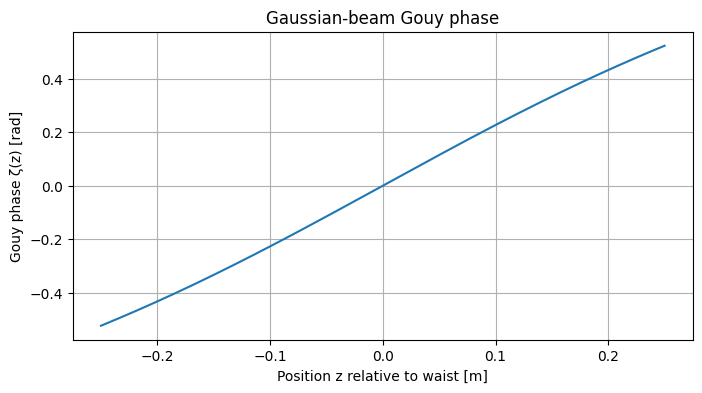

Adjacent transverse-mode frequency scale ≈ 99.931 MHz


In [8]:
gouy = np.arctan(z/zR)

plt.figure(figsize=(8, 4))
plt.plot(z, gouy)
plt.xlabel("Position z relative to waist [m]")
plt.ylabel("Gouy phase ζ(z) [rad]")
plt.title("Gaussian-beam Gouy phase")
plt.grid(True)
plt.show()

transverse_spacing = FSR * np.arccos(np.sqrt(g_product)) / pi
print(f"Adjacent transverse-mode frequency scale ≈ {transverse_spacing/1e6:.3f} MHz")

## 10. Gaussian intensity inside the cavity

For a Gaussian beam carrying power $P_{\rm cav}$,

$$
\boxed{
I(r,z)
=
\frac{2P_{\rm cav}}{\pi w^2(z)}
\exp\left[-\frac{2r^2}{w^2(z)}\right]
}.
$$

On the beam axis,

$$
\boxed{
I_{\rm peak}(z)
=
\frac{2P_{\rm cav}}{\pi w^2(z)}
}.
$$

Therefore, for fixed circulating power, the intensity is largest where the beam is narrowest: at the waist.

This is directly relevant to the later nonlinear-crystal model, where the optical intensity determines the strength of the nonlinear interaction.

Peak resonant intensity at waist = 434.098 MW/m²
Peak resonant intensity at waist = 43409.795 W/cm²


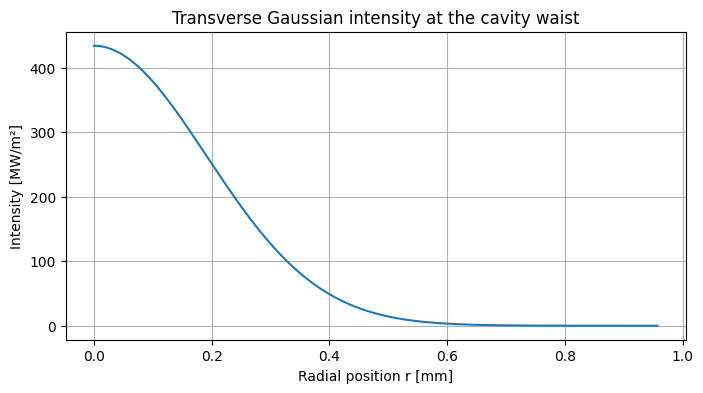

In [9]:
def gaussian_intensity(r, z, P, w0, zR):
    wz = w0 * np.sqrt(1 + (z/zR)**2)
    return (
        2 * P / (pi * wz**2)
        * np.exp(-2 * r**2 / wz**2)
    )

I_peak_waist = 2 * P_cav_res / (pi * w0**2)

print(f"Peak resonant intensity at waist = {I_peak_waist/1e6:.3f} MW/m²")
print(f"Peak resonant intensity at waist = {I_peak_waist/1e4:.3f} W/cm²")

r = np.linspace(0, 2.5*w0, 600)
I_r = gaussian_intensity(r, 0.0, P_cav_res, w0, zR)

plt.figure(figsize=(8, 4))
plt.plot(r*1e3, I_r/1e6)
plt.xlabel("Radial position r [mm]")
plt.ylabel("Intensity [MW/m²]")
plt.title("Transverse Gaussian intensity at the cavity waist")
plt.grid(True)
plt.show()

## 11. Power check: does the Gaussian intensity contain the circulating power?

The Gaussian intensity profile must integrate to the circulating power:

$$
\boxed{
P=
\int_0^\infty I(r,z)\,2\pi r\,dr
}.
$$

This is a useful numerical sanity check: the spatial intensity model should redistribute the circulating power, not create additional power.

In [10]:
r_check = np.linspace(0, 5*w0, 20000)

I_check = gaussian_intensity(
    r_check, 0.0, P_cav_res, w0, zR
)

P_integrated = np.trapezoid(
    I_check * 2*pi*r_check,
    r_check
)

print(f"Circulating power from cavity buildup = {P_cav_res:.9f} W")
print(f"Gaussian transverse integral = {P_integrated:.9f} W")
print(f"Relative error = {(P_integrated-P_cav_res)/P_cav_res:.3e}")

Circulating power from cavity buildup = 100.000000000 W
Gaussian transverse integral = 99.999997916 W
Relative error = -2.084e-08


## 12. Peak intensity along the cavity

In an ideal lossless cavity, the total circulating power does not change as the beam propagates. The beam area does change, however.

Thus

$$
\boxed{
I_{\rm peak}(z)=
\frac{2P_{\rm cav}}{\pi w^2(z)}
}.
$$

The peak intensity is therefore largest at the waist.

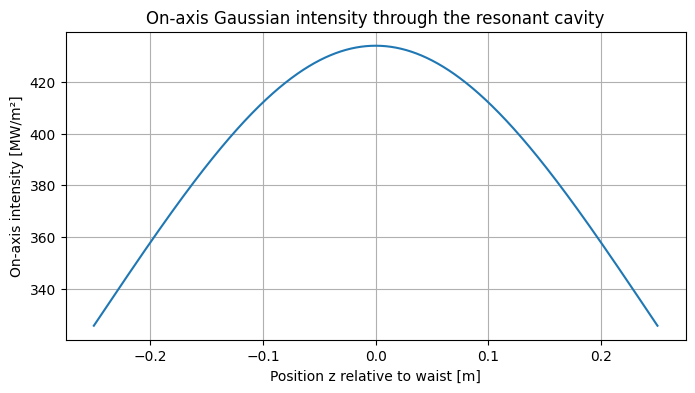

Peak intensity occurs at z = -2.502503e-04 m
Peak intensity = 434.098 MW/m²


In [11]:
I_peak_z = 2 * P_cav_res / (pi * w**2)

plt.figure(figsize=(8, 4))
plt.plot(z, I_peak_z/1e6)
plt.xlabel("Position z relative to waist [m]")
plt.ylabel("On-axis intensity [MW/m²]")
plt.title("On-axis Gaussian intensity through the resonant cavity")
plt.grid(True)
plt.show()

print(f"Peak intensity occurs at z = {z[np.argmax(I_peak_z)]:.6e} m")
print(f"Peak intensity = {I_peak_z.max()/1e6:.3f} MW/m²")

## 13. Detuning changes the intracavity Gaussian intensity

The cavity geometry determines the Gaussian mode, but the circulating power depends strongly on frequency detuning.

At the waist,

$$
\boxed{
I_{\rm peak}(\delta\nu)
=
\frac{2B(\delta\nu)P_{\rm in}}
{\pi w_0^2}
}.
$$

Thus, as the input frequency moves toward resonance:

$$
P_{\rm cav}\uparrow
\quad\Rightarrow\quad
I_{\rm peak}\uparrow
\quad\Rightarrow\quad
E_{\rm optical}\propto\sqrt{I}\uparrow.
$$

The final step will matter when the nonlinear interaction is introduced.

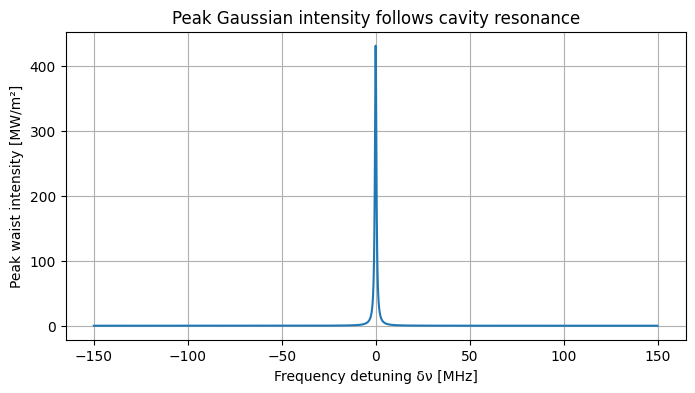

In [12]:
I_peak_detuning = 2 * P_cav / (pi * w0**2)

plt.figure(figsize=(8, 4))
plt.plot(delta_nu/1e6, I_peak_detuning/1e6)
plt.xlabel("Frequency detuning δν [MHz]")
plt.ylabel("Peak waist intensity [MW/m²]")
plt.title("Peak Gaussian intensity follows cavity resonance")
plt.grid(True)
plt.show()

## 14. Symmetric versus asymmetric Fabry–Pérot cavities

The symmetric case has

$$
ROC_1=ROC_2,
$$

so the waist lies at the cavity centre.

If

$$
ROC_1\neq ROC_2,
$$

the cavity is asymmetric. The natural waist generally moves away from the centre, and its Rayleigh range changes.

The simple symmetric formulas above are therefore no longer sufficient to determine the complete Gaussian eigenmode.

At this stage we can understand the physical effect qualitatively:

$$
ROC_1\neq ROC_2
\quad\Rightarrow\quad
\text{waist position changes},
$$

$$
\text{and}\qquad
z_R\text{ changes}.
$$

The systematic way to calculate the asymmetric eigenmode is the **ABCD round-trip matrix**, which is developed in the next notebook, 02C.

## 15. Parameter studies

The model lets us see two important geometric dependencies.

### Mirror curvature

For the symmetric cavity,

$$
ROC\rightarrow g_1,g_2
\rightarrow z_R
\rightarrow w_0.
$$

Changing the mirror curvature therefore changes the transverse mode.

### Cavity length

Longitudinally,

$$
L\uparrow\Rightarrow \mathrm{FSR}=\frac{c}{2L}\downarrow.
$$

At fixed mirror curvature, changing $L$ also changes the $g$-factors and therefore changes the Gaussian mode.

So cavity length affects both longitudinal and transverse physics.

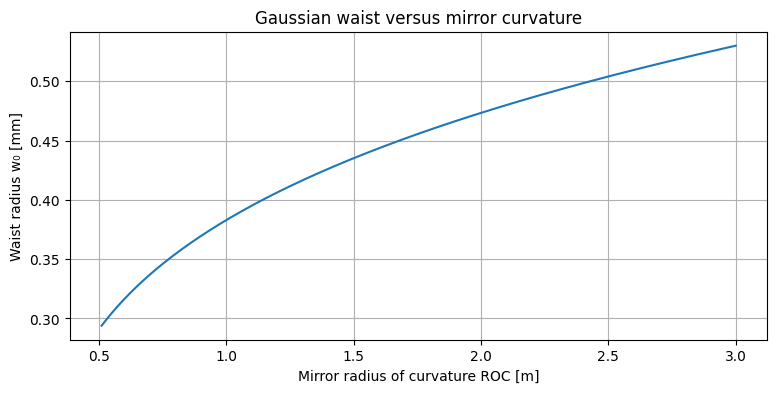

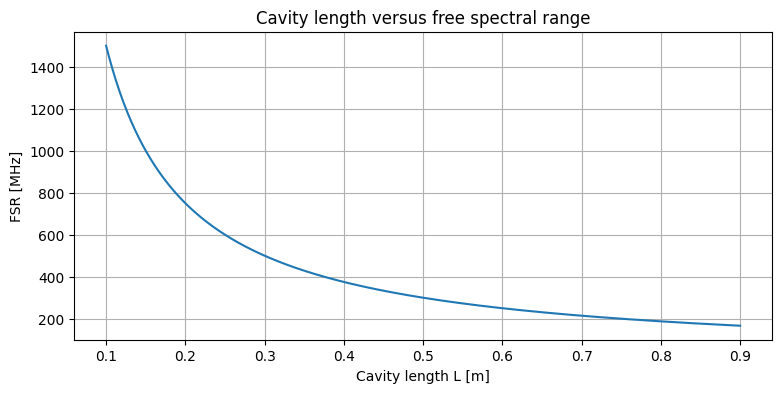

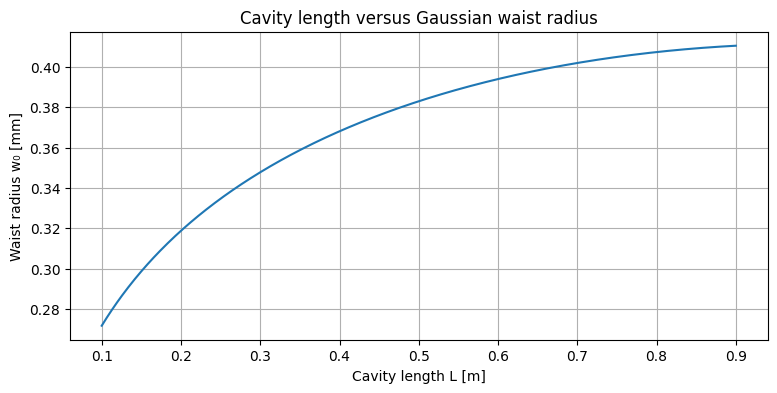

In [13]:
ROC_values = np.linspace(0.51, 3.0, 500)

g_values = 1 - L / ROC_values
stable_mask = (g_values**2 > 0) & (g_values**2 < 1)

zR_values = np.full_like(ROC_values, np.nan)
w0_values = np.full_like(ROC_values, np.nan)

zR_values[stable_mask] = np.sqrt(
    (L/2) * (ROC_values[stable_mask] - L/2)
)

w0_values[stable_mask] = np.sqrt(
    lambda0 * zR_values[stable_mask] / pi
)

plt.figure(figsize=(9, 4))
plt.plot(ROC_values[stable_mask], w0_values[stable_mask]*1e3)
plt.xlabel("Mirror radius of curvature ROC [m]")
plt.ylabel("Waist radius w₀ [mm]")
plt.title("Gaussian waist versus mirror curvature")
plt.grid(True)
plt.show()

L_values = np.linspace(0.10, 0.90, 500)

FSR_values = c / (2 * L_values)
stable_L = (L_values > 0) & (L_values < 2*ROC1)

zR_L = np.full_like(L_values, np.nan)
w0_L = np.full_like(L_values, np.nan)

zR_L[stable_L] = np.sqrt(
    (L_values[stable_L]/2)
    * (ROC1 - L_values[stable_L]/2)
)

w0_L[stable_L] = np.sqrt(
    lambda0 * zR_L[stable_L] / pi
)

plt.figure(figsize=(9, 4))
plt.plot(L_values, FSR_values/1e6)
plt.xlabel("Cavity length L [m]")
plt.ylabel("FSR [MHz]")
plt.title("Cavity length versus free spectral range")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(L_values, w0_L*1e3)
plt.xlabel("Cavity length L [m]")
plt.ylabel("Waist radius w₀ [mm]")
plt.title("Cavity length versus Gaussian waist radius")
plt.grid(True)
plt.show()

## 16. Internal loss

A real cavity has absorption, scattering, imperfect coatings, and eventually nonlinear-crystal loss.

If the internal round-trip power transmission is $T_{\rm rt}<1$,

$$
\boxed{
B_{\rm res}
=
\frac{T_1}
{\left(1-\sqrt{R_1R_2T_{\rm rt}}\right)^2}
}.
$$

Internal loss therefore reduces the achievable circulating power. This will become particularly important once a nonlinear crystal is introduced.

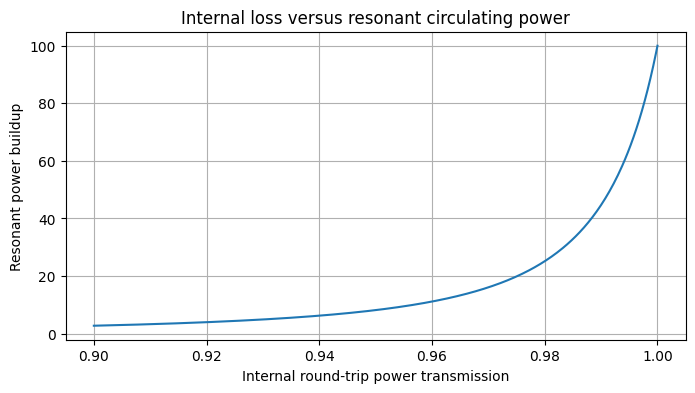

In [14]:
loss_values = np.linspace(0.90, 1.0, 400)

B_loss = mirror_T1 / (
    1 - np.sqrt(mirror_R1 * mirror_R2 * loss_values)
)**2

plt.figure(figsize=(8, 4))
plt.plot(loss_values, B_loss)
plt.xlabel("Internal round-trip power transmission")
plt.ylabel("Resonant power buildup")
plt.title("Internal loss versus resonant circulating power")
plt.grid(True)
plt.show()

## 17. What this model establishes

We have connected the basic linear cavity physics:

$$
\boxed{
\text{geometry}
\rightarrow
\text{stability}
\rightarrow
\text{Gaussian mode}
}
$$

and

$$
\boxed{
\text{resonance}
\rightarrow
\text{power buildup}
\rightarrow
\text{Gaussian intensity}
}.
$$

For the symmetric cavity, the mode can be obtained directly from the geometry. For an asymmetric cavity, the waist position and Rayleigh range must be determined more generally.

### Important distinction

$$
\boxed{B=P_{\rm cav}/P_{\rm in}}
$$

is cavity buildup, **not OPO gain**.

No nonlinear amplification has been included in this model.

### Next model

**02C — ABCD Matrix Treatment of the Fabry–Pérot Cavity**

will provide the systematic method for calculating the Gaussian eigenmode of both symmetric and asymmetric cavities and will establish the ABCD approach that we later use for the four-mirror bow-tie cavity.